In [1]:
pip install pandas numpy scikit-learn matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

import warnings
warnings.filterwarnings("ignore")


In [3]:
data = pd.read_csv("hour.csv")

print("Shape:", data.shape)
data.head()


Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
print(data.isnull().sum())


instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


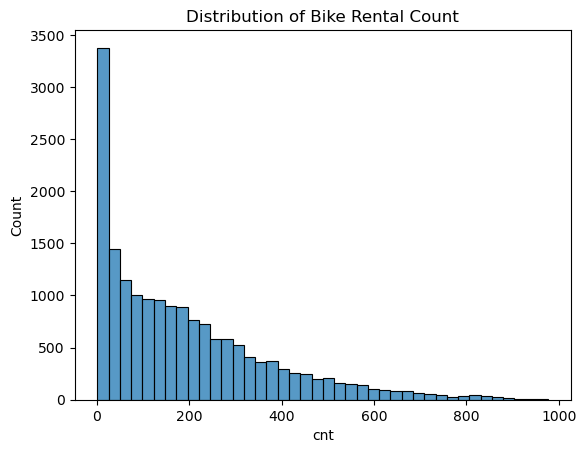

In [6]:
plt.figure()
sns.histplot(data["cnt"], bins=40)
plt.title("Distribution of Bike Rental Count")
plt.show()


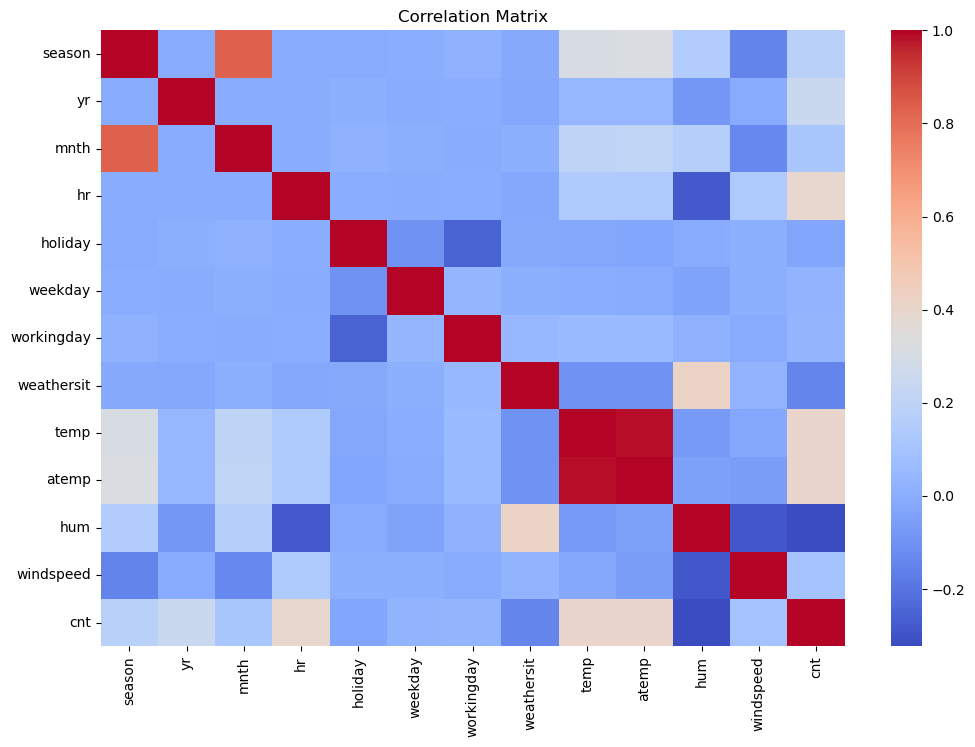

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


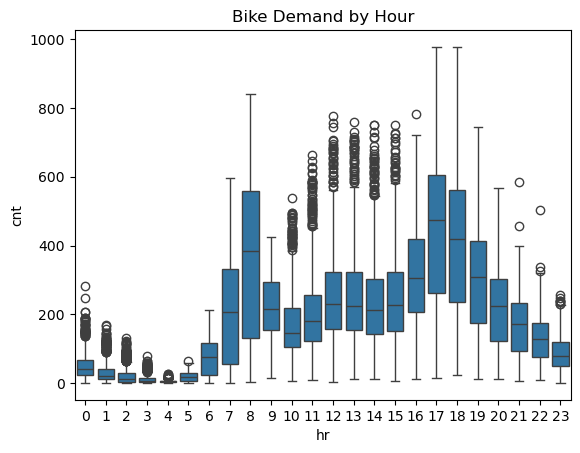

In [5]:
plt.figure()
sns.boxplot(x="hr", y="cnt", data=data)
plt.title("Bike Demand by Hour")
plt.show()
drop_cols = ["instant", "dteday", "casual", "registered"]
data = data.drop(columns=drop_cols)


In [8]:
#feature engineering
drop_cols = ["instant", "dteday", "casual", "registered"]
data = data.drop(columns=drop_cols)


KeyError: "['instant', 'dteday', 'casual', 'registered'] not found in axis"

In [9]:
data["hr_sin"] = np.sin(2 * np.pi * data["hr"] / 24)
data["hr_cos"] = np.cos(2 * np.pi * data["hr"] / 24)

data["mnth_sin"] = np.sin(2 * np.pi * data["mnth"] / 12)
data["mnth_cos"] = np.cos(2 * np.pi * data["mnth"] / 12)


In [10]:
data = data.drop(columns=["hr", "mnth"])


In [11]:
X = data.drop(columns=["cnt"])
y = data["cnt"]

print("Feature shape:", X.shape)


Feature shape: (17379, 14)


In [12]:
# K fold
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)


In [13]:
#random forest

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)


In [14]:
subag_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=15),
    n_estimators=200,
    max_samples=0.6,
    random_state=42
)


In [15]:
boost_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])


In [16]:
def run_cv(model, name):

    rmse_list = []
    mae_list = []

    for train_index, test_index in kf.split(X):

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)

        rmse_list.append(rmse)
        mae_list.append(mae)

    print("-----", name, "-----")
    print("RMSE:", np.mean(rmse_list), "±", np.std(rmse_list))
    print("MAE :", np.mean(mae_list), "±", np.std(mae_list))
    print()

    return [name, np.mean(rmse_list), np.std(rmse_list),
            np.mean(mae_list), np.std(mae_list)]


In [ ]:
rf_result = run_cv(rf_model, "RandomForest (Bagging)")
subag_result = run_cv(subag_model, "Subagging")
boost_result = run_cv(boost_pipeline, "GradientBoosting")


----- RandomForest (Bagging) -----
RMSE: 42.37216317707853 ± 0.8453357959135825
MAE : 25.412552355100974 ± 0.5408750211908264

----- Subagging -----
RMSE: 42.42787911565389 ± 1.0056821484083396
MAE : 25.736624556527364 ± 0.5925614446673968



In [ ]:
results = pd.DataFrame(
    [rf_result, subag_result, boost_result],
    columns=["Model", "RMSE_mean", "RMSE_std", "MAE_mean", "MAE_std"]
)

results.to_csv("cv_regression_results.csv", index=False)
results


In [ ]:
best_model = boost_pipeline
best_model.fit(X, y)

preds = best_model.predict(X)

final_df = pd.DataFrame({
    "ActualCnt": y,
    "PredictedCnt": preds
})

final_df.to_csv("final_predictions.csv", index=False)


In [ ]:
model = boost_pipeline.named_steps["model"]

importances = model.feature_importances_

feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_df = feature_df.sort_values(by="Importance", ascending=False)

top8 = feature_df.head(8)
top8


In [ ]:
plt.figure()
sns.barplot(x="Importance", y="Feature", data=top8)
plt.title("Top 8 Important Features")
plt.show()


In [ ]:
Important Features:

temp

atemp

hr_sin / hr_cos

workingday

season

weathersit